<center>
    
## Investigacion inicial COMPLETA - Tesis
**Camila Uribe - 202217043**
</center>

In [5]:
import sympy as smp
from sympy import sin, cos, tan, Symbol, symbols
from sympy.physics.vector import cross
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, least_squares
from scipy.optimize import least_squares
from scipy.integrate import odeint
from sympy import symbols, Eq, solve
from scipy.interpolate import interp1d
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.gridspec import GridSpec
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.optimize import Bounds
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

<center>

### Parte 1: Encontrando el K en aire

<center>

#### Primera toma de datos

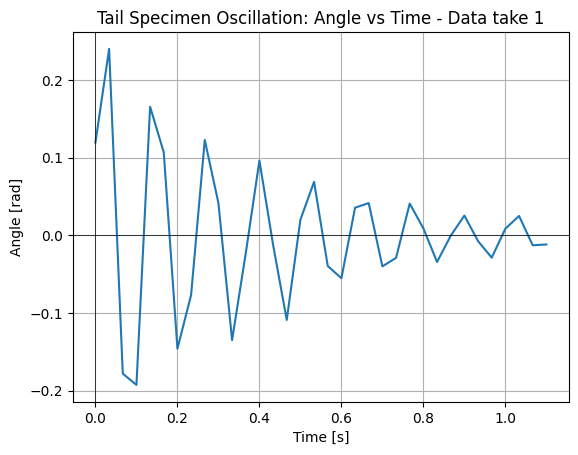

In [28]:
df = pd.read_csv("tail_air_protractor.txt", sep=';', skiprows=1, comment='#')
df = df.drop(columns=['Unnamed: 2'])
df = df.iloc[:-10]
df = df.iloc[5:]
t_exp = df['t'].to_numpy()
t_exp = t_exp - t_exp[0]
theta_deg_exp = df['θ'].to_numpy()
theta_exp = np.deg2rad(theta_deg_exp) 
N = max(1, len(theta_exp)//10)   # last 10% of samples
offset = np.mean(theta_exp[-N:]) # average final angle
theta_zeroed = theta_exp - offset
plt.plot(t_exp, theta_zeroed)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.title('Tail Specimen Oscillation: Angle vs Time - Data take 1')
plt.grid()
plt.show()

In [7]:
peaks, _   = find_peaks(theta_zeroed, prominence=np.deg2rad(0.001))
troughs, _ = find_peaks(-theta_zeroed, prominence=np.deg2rad(0.001))

Tp = np.diff(t_exp[peaks])    # seconds
Tt = np.diff(t_exp[troughs])  # seconds
T_all = np.concatenate([Tp, Tt])

T_mean = np.mean(T_all)
T_std  = np.std (T_all, ddof=1) if T_all.size>1 else np.nan

omega_d = 2*np.pi / T_mean
f_d     = 1.0 / T_mean

print(f"cycles used: peaks={len(Tp)}, troughs={len(Tt)}")
print(f"T_mean = {T_mean:.6f} s  (± {T_std:.6f})")
print(f"f_d    = {f_d:.6f} Hz")
print(f"ω_d    = {omega_d:.6f} rad/s")

cycles used: peaks=8, troughs=8
T_mean = 0.123045 s  (± 0.015974)
f_d    = 8.127127 Hz
ω_d    = 51.064247 rad/s


In [8]:
theta_s = np.convolve(theta_zeroed, np.ones(5)/5, mode='same')
mask = t_exp > (t_exp.max() - 0.8)
tt = t_exp[mask] - t_exp[mask][0]
yy = theta_s[mask]

def damped_cos(t, A, alpha, w, phi, C):
    return A*np.exp(-alpha*t)*np.cos(w*t + phi) + C

# Initial guesses
A0   = np.ptp(yy)/2
w0   = 2*np.pi*f_d          
alpha0 = 1.0                # light damping (s^-1); adjust if needed
p0   = (A0, alpha0, w0, 0.0, 0.0)

pars, pcov = curve_fit(damped_cos, tt, yy, p0=p0, maxfev=20000)
A, alpha, w_d, phi, C = pars
perr = np.sqrt(np.diag(pcov))  # 1-sigma std errors

# Frequencies & damping
omega_d = w_d
omega_n = np.sqrt(omega_d**2 + alpha**2)  # since omega_d = omega_n*sqrt(1-ζ^2) and alpha = ζ*omega_n
zeta    = alpha / omega_n

print(f"alpha={alpha:.4f} 1/s, ω_d={omega_d:.4f} rad/s")
print(f"ω_n={omega_n:.4f} rad/s,  ζ={zeta:.4f}")

alpha=2.3190 1/s, ω_d=50.2852 rad/s
ω_n=50.3387 rad/s,  ζ=0.0461


In [9]:
g = 9.81
m = 0.0022319   # kg  <-- EDITAR
L = 0.030   # m 

I    = (1/3)*m*L**2
ell  = L/2

k_theta = I*omega_n**2 - m*g*ell
EI      = k_theta*L/3
k_tip   = k_theta / L**2

print(f"I = {I:.6e} kg·m²")
print(f"k_theta = {k_theta:.3f} N·m/rad")
print(f"EI = {EI:.6e} N·m²,  k_tip = {k_tip:.3f} N/m")

I = 6.695700e-07 kg·m²
k_theta = 0.001 N·m/rad
EI = 1.368253e-05 N·m²,  k_tip = 1.520 N/m


<center>

#### Segunda toma de datos

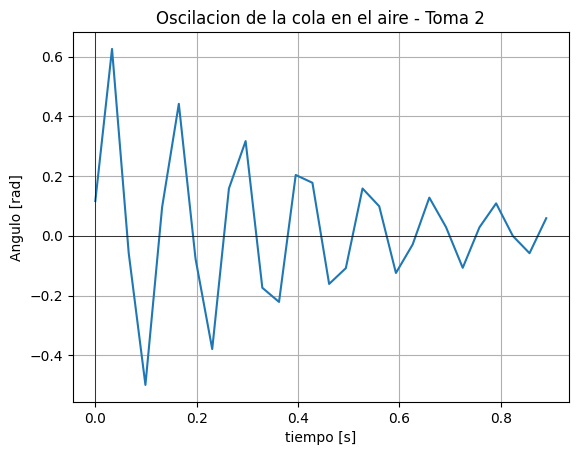

In [10]:
df2 = pd.read_csv("tail_air_protractor2.txt", sep=';', skiprows=1, comment='#')
df2 = df2.drop(columns=['Unnamed: 2'])
df2 = df2.iloc[:-2]
df2 = df2.iloc[1:]
t_exp2 = df2['t'].to_numpy()
t_exp2 = t_exp2 - t_exp2[0]
theta_deg_exp2 = df2['θ'].to_numpy()
theta_exp2 = np.deg2rad(theta_deg_exp2) 
N2 = max(1, len(theta_exp2)//10)   # last 10% of samples
offset2 = np.mean(theta_exp2[-N:]) # average final angle
theta_zeroed2 = theta_exp2 - offset2
plt.plot(t_exp2, theta_zeroed2)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('tiempo [s]')
plt.ylabel('Angulo [rad]')
plt.title('Oscilacion de la cola en el aire - Toma 2')
plt.grid()
plt.show()

In [11]:
peaks2, _   = find_peaks(theta_zeroed2, prominence=np.deg2rad(0.001))
troughs2, _ = find_peaks(-theta_zeroed2, prominence=np.deg2rad(0.001))

Tp2 = np.diff(t_exp2[peaks2])    # seconds
Tt2 = np.diff(t_exp2[troughs2])  # seconds
T_all2 = np.concatenate([Tp2, Tt2])

T_mean2 = np.mean(T_all2)
T_std2  = np.std (T_all2, ddof=1) if T_all2.size>1 else np.nan

omega_d2 = 2*np.pi / T_mean2
f_d2     = 1.0 / T_mean2

print(f"cycles used: peaks={len(Tp2)}, troughs={len(Tt2)}")
print(f"T_mean = {T_mean2:.6f} s  (± {T_std2:.6f})")
print(f"f_d    = {f_d2:.6f} Hz")
print(f"ω_d    = {omega_d2:.6f} rad/s")

cycles used: peaks=6, troughs=6
T_mean = 0.126287 s  (± 0.012824)
f_d    = 7.918469 Hz
ω_d    = 49.753210 rad/s


In [12]:
# Use the same window you used (last ~1 s), already smoothed/zeroed
theta_s2 = np.convolve(theta_zeroed2, np.ones(5)/5, mode='same')
mask2 = t_exp2 > (t_exp2.max() - 1.0)
tt2 = t_exp2[mask2] - t_exp2[mask2][0]
yy2 = theta_s2[mask2]

def damped_cos(t, A, alpha, w, phi, C):
    return A*np.exp(-alpha*t)*np.cos(w*t + phi) + C

# Initial guesses
A02   = np.ptp(yy2)/2
w02   = 2*np.pi*f_d2          
alpha02 = 1.0                # light damping (s^-1); adjust if needed
p0   = (A02, alpha02, w02, 0.0, 0.0)

pars2, pcov2 = curve_fit(damped_cos, tt2, yy2, p0=p0, maxfev=20000)
A2, alpha2, w_d2, phi2, C2 = pars2
perr = np.sqrt(np.diag(pcov2))  # 1-sigma std errors

# Frequencies & damping
omega_d2 = w_d2
omega_n2 = np.sqrt(omega_d2**2 + alpha2**2)  # since omega_d = omega_n*sqrt(1-ζ^2) and alpha = ζ*omega_n
zeta2    = alpha2 / omega_n2

print(f"alpha={alpha2:.4f} 1/s, ω_d={omega_d2:.4f} rad/s")
print(f"ω_n={omega_n2:.4f} rad/s,  ζ={zeta2:.4f}")

alpha=1.3605 1/s, ω_d=51.2431 rad/s
ω_n=51.2611 rad/s,  ζ=0.0265


In [13]:
k_theta2 = I*omega_n2**2 - m*g*ell
EI2      = k_theta2*L/3
k_tip2   = k_theta2 / L**2

print(f"I = {I:.6e} kg·m²")
print(f"k_theta = {k_theta:.3f} N·m/rad")
print(f"EI = {EI2:.6e} N·m²,  k_tip = {k_tip2:.3f} N/m")

I = 6.695700e-07 kg·m²
k_theta = 0.001 N·m/rad
EI = 1.431007e-05 N·m²,  k_tip = 1.590 N/m


<center>

#### Tercera toma de datos

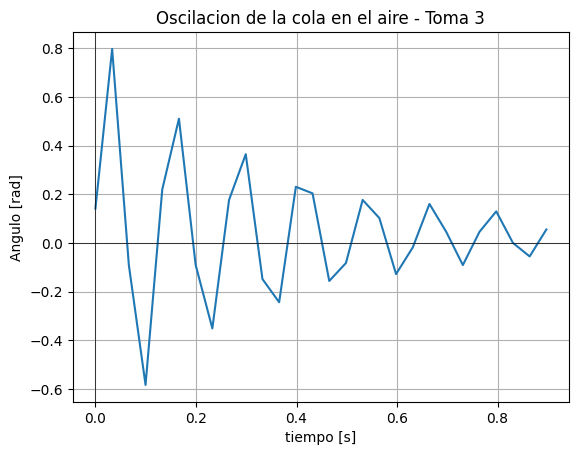

In [14]:
df3 = pd.read_csv("tail_air_protractor3.txt", sep=';', skiprows=1, comment='#')
df3 = df3.drop(columns=['Unnamed: 2'])
df3 = df3.iloc[:-2]
df3 = df3.iloc[1:]
t_exp3 = df3['t'].to_numpy()
t_exp3 = t_exp3 - t_exp3[0]
theta_deg_exp3 = df3['θ'].to_numpy()
theta_exp3 = np.deg2rad(theta_deg_exp3) 
N2 = max(1, len(theta_exp3)//10)   # last 10% of samples
offset3 = np.mean(theta_exp3[-N:]) # average final angle
theta_zeroed3 = theta_exp3 - offset3

plt.plot(t_exp3, theta_zeroed3)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('tiempo [s]')
plt.ylabel('Angulo [rad]')
plt.title('Oscilacion de la cola en el aire - Toma 3')
plt.grid()
plt.show()

In [15]:
peaks3, _   = find_peaks(theta_zeroed3, prominence=np.deg2rad(0.001))
troughs3, _ = find_peaks(-theta_zeroed3, prominence=np.deg2rad(0.001))

Tp3 = np.diff(t_exp3[peaks3])    # seconds
Tt3 = np.diff(t_exp3[troughs3])  # seconds
T_all3 = np.concatenate([Tp3, Tt3])

T_mean3 = np.mean(T_all3)
T_std3 = np.std (T_all3, ddof=1) if T_all3.size>1 else np.nan

omega_d3 = 2*np.pi / T_mean3
f_d3     = 1.0 / T_mean3

print(f"cycles used: peaks={len(Tp3)}, troughs={len(Tt3)}")
print(f"T_mean = {T_mean3:.6f} s  (± {T_std3:.6f})")
print(f"f_d    = {f_d3:.6f} Hz")
print(f"ω_d    = {omega_d3:.6f} rad/s")

cycles used: peaks=6, troughs=6
T_mean = 0.127352 s  (± 0.012932)
f_d    = 7.852261 Hz
ω_d    = 49.337211 rad/s


In [16]:
# Use the same window you used (last ~1 s), already smoothed/zeroed
theta_s3 = np.convolve(theta_zeroed3, np.ones(5)/5, mode='same')
mask3 = t_exp3 > (t_exp3.max() - 1.0)
tt3 = t_exp3[mask3] - t_exp3[mask3][0]
yy3 = theta_s3[mask3]

def damped_cos(t, A, alpha, w, phi, C):
    return A*np.exp(-alpha*t)*np.cos(w*t + phi) + C

# Initial guesses
A03   = np.ptp(yy3)/2
w03   = 2*np.pi*f_d3          
alpha03 = 1.0                # light damping (s^-1); adjust if needed
p0   = (A03, alpha03, w03, 0.0, 0.0)

pars3, pcov3 = curve_fit(damped_cos, tt3, yy3, p0=p0, maxfev=20000)
A3, alpha3, w_d3, phi3, C3 = pars3
perr = np.sqrt(np.diag(pcov3))  # 1-sigma std errors

# Frequencies & damping
omega_d3 = w_d3
omega_n3 = np.sqrt(omega_d3**2 + alpha3**2)  # since omega_d = omega_n*sqrt(1-ζ^2) and alpha = ζ*omega_n
zeta3    = alpha3 / omega_n3

print(f"alpha={alpha3:.4f} 1/s, ω_d={omega_d3:.4f} rad/s")
print(f"ω_n={omega_n3:.4f} rad/s,  ζ={zeta3:.4f}")

alpha=1.4400 1/s, ω_d=50.7550 rad/s
ω_n=50.7754 rad/s,  ζ=0.0284


In [17]:
k_theta3 = I*omega_n3**2 - m*g*ell
EI3      = k_theta3*L/3
k_tip3   = k_theta3 / L**2

print(f"I = {I:.6e} kg·m²")
print(f"k_theta = {k_theta3:.3f} N·m/rad")
print(f"EI = {EI3:.6e} N·m²,  k_tip = {k_tip3:.3f} N/m")

I = 6.695700e-07 kg·m²
k_theta = 0.001 N·m/rad
EI = 1.397823e-05 N·m²,  k_tip = 1.553 N/m


In [ ]:
kf = (k_tip + k_tip2 + k_tip3)/3 
zetaf = (zeta + zeta2 + zeta3)/3 

print(kf, zetaf)

1.5544751078328074 0.03365553842876919


<center>

### Parte 2: Encontrarel c en agua

<center>


#### Primera toma de datos

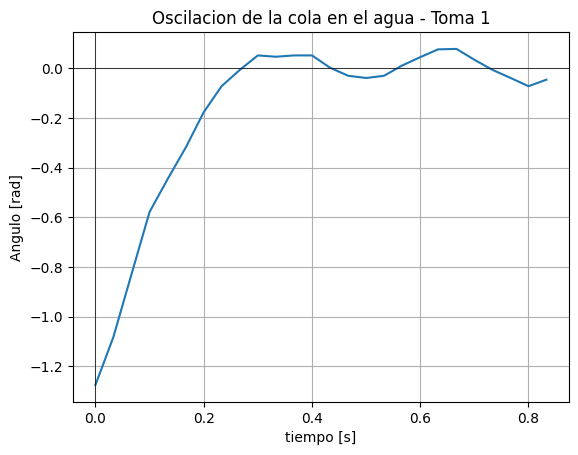

In [19]:
df_a1 = pd.read_csv("pez_agua_c_datos.txt", sep=';', skiprows=1, comment='#')
df_a1 = df_a1.drop(columns=['Unnamed: 2'])
df_a1 = df_a1.iloc[:-3]
t_a1 = df_a1['t'].to_numpy()
t_a1 = t_a1 - t_a1[0]
theta_deg_a1 = df_a1['θ'].to_numpy()
theta_a1 = np.deg2rad(theta_deg_a1) - 0.03
plt.plot(t_a1, theta_a1)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('tiempo [s]')
plt.ylabel('Angulo [rad]')
plt.title('Oscilacion de la cola en el agua - Toma 1')
plt.grid()
plt.show()

Mejor coeficiente de amortiguamiento c = 0.16939


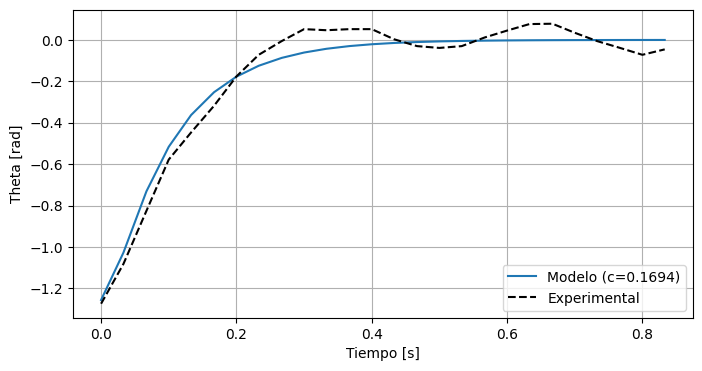

In [20]:
def odefun(q, t, k, c, m):
    theta, thetadot = q
    thetaddot = -(k/m)*theta - (c/m)*thetadot
    return [thetadot, thetaddot]
 
q0 = [-np.pi/2.5, 0] 

c_values = np.linspace(0.05, 0.5, 50)   
errors = []

for c in c_values:
    qq = odeint(odefun, q0, t_a1, args=(kf, c, m))
    theta_model = qq[:, 0]
    error = np.mean((theta_model - theta_a1)**2)
    errors.append(error)

# Find the c with minimum error
best_c = c_values[np.argmin(errors)]
print(f"Mejor coeficiente de amortiguamiento c = {best_c:.5f}")

qq_best = odeint(odefun, q0, t_a1, args=(kf, best_c, m))

plt.figure(figsize=(8,4))
plt.plot(t_a1, qq_best[:,0], label=f"Modelo (c={best_c:.4f})")
plt.plot(t_a1, theta_a1, 'k--', label="Experimental")
plt.xlabel("Tiempo [s]")
plt.ylabel("Theta [rad]")
plt.legend()
plt.grid()
plt.show()

<center>


#### Segunda toma de datos

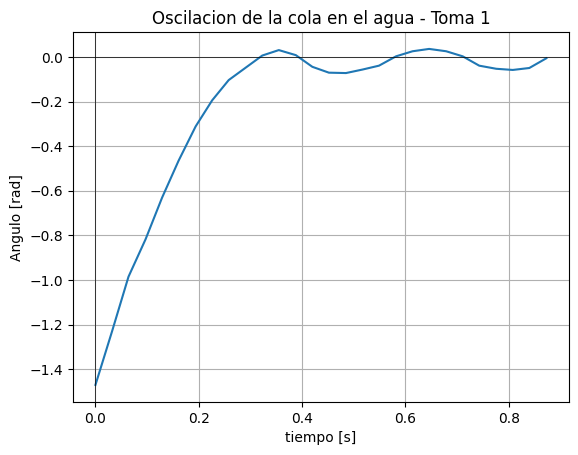

In [21]:
df_a2 = pd.read_csv("tail_water_c2.txt", sep=';', skiprows=1, comment='#')
df_a2 = df_a2.drop(columns=['Unnamed: 2'])
df_a2 = df_a2.iloc[2:]
df_a2 = df_a2.iloc[:-1]
t_a2 = df_a2['t'].to_numpy()
t_a2 = t_a2 - t_a2[0]
theta_deg_a2 = df_a2['θ'].to_numpy()
theta_a2 = np.deg2rad(theta_deg_a2)+0.02
plt.plot(t_a2, theta_a2)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('tiempo [s]')
plt.ylabel('Angulo [rad]')
plt.title('Oscilacion de la cola en el agua - Toma 1')
plt.grid()
plt.show()

Mejor coeficiente de amortiguamiento c = 0.19694


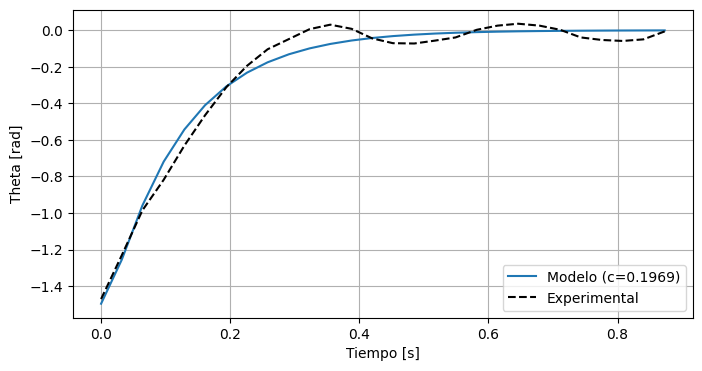

In [22]:
q0_2 = [-np.pi/2.1, 0] 
errors2 = []

for c in c_values:
    qq = odeint(odefun, q0_2, t_a2, args=(kf, c, m))
    theta_model = qq[:, 0]
    error2 = np.mean((theta_model - theta_a2)**2)
    errors2.append(error2)

best_c2 = c_values[np.argmin(errors2)]
print(f"Mejor coeficiente de amortiguamiento c = {best_c2:.5f}")

qq_best = odeint(odefun, q0_2, t_a2, args=(kf, best_c2, m))

plt.figure(figsize=(8,4))
plt.plot(t_a2, qq_best[:,0], label=f"Modelo (c={best_c2:.4f})")
plt.plot(t_a2, theta_a2, 'k--', label="Experimental")
plt.xlabel("Tiempo [s]")
plt.ylabel("Theta [rad]")
plt.legend()
plt.grid()
plt.show()

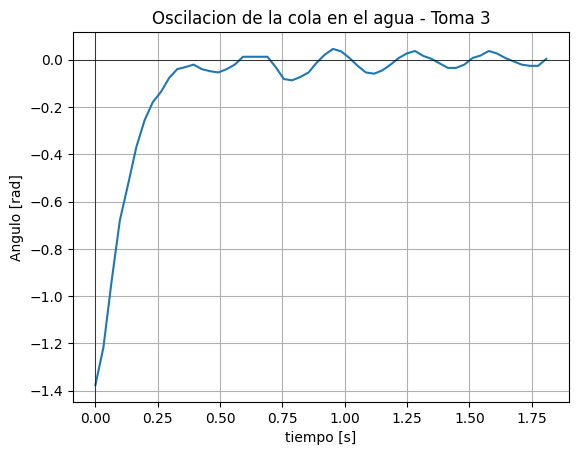

In [ ]:
df_a3 = pd.read_csv("tail_water_c3.txt", sep=';', skiprows=1, comment='#')
df_a3 = df_a3.drop(columns=['Unnamed: 2'])
df_a3 = df_a3.iloc[4:]
df_a3 = df_a3.iloc[:-5]
t_a3 = df_a3['t'].to_numpy()
t_a3 = t_a3 - t_a3[0]
theta_deg_a3 = df_a3['θ'].to_numpy()
theta_a3 = np.deg2rad(theta_deg_a3)
plt.plot(t_a3, theta_a3)
plt.axhline(0, color='black', linewidth=0.5, linestyle='-')  # Black, thicker solid line for y=0
plt.axvline(0, color='black', linewidth=0.5, linestyle='-')
plt.xlabel('tiempo [s]')
plt.ylabel('Angulo [rad]')
plt.title('Tail Specimen Underwater Oscillation: Angle vs Time - Data take 3')
plt.grid()
plt.show()

Mejor coeficiente de amortiguamiento c = 0.19694


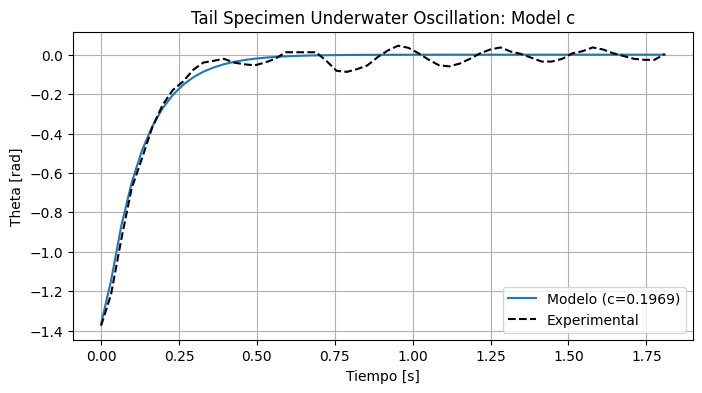

In [29]:
q0_3 = [-np.pi/2.3, 0] 
errors3 = []

for c in c_values:
    qq = odeint(odefun, q0_3, t_a3, args=(kf, c, m))
    theta_model = qq[:, 0]
    error3 = np.mean((theta_model - theta_a3)**2)
    errors3.append(error3)

best_c3 = c_values[np.argmin(errors3)]
print(f"Mejor coeficiente de amortiguamiento c = {best_c3:.5f}")

qq_best = odeint(odefun, q0_3, t_a3, args=(kf, best_c3, m))

plt.figure(figsize=(8,4))
plt.plot(t_a3, qq_best[:,0], label=f"Modelo (c={best_c3:.4f})")
plt.plot(t_a3, theta_a3, 'k--', label="Experimental")
plt.xlabel("Tiempo [s]")
plt.ylabel("Theta [rad]")
plt.title('Tail Specimen Underwater Oscillation: Model c')
plt.legend()
plt.grid()
plt.show()

In [25]:
cf = round((best_c3 + best_c2 + best_c)/3,2)
cf

np.float64(0.19)

<center>

### Parte 3: Angulos, velocidad angular y aceleración angular

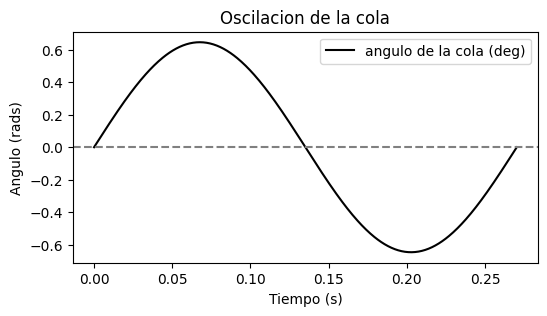

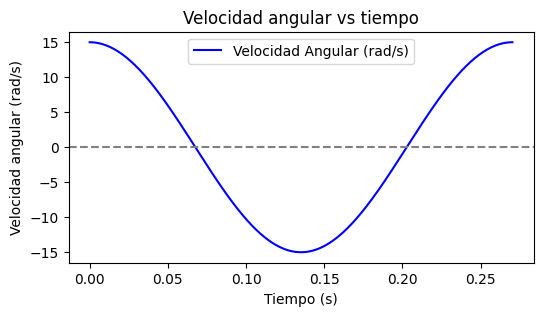

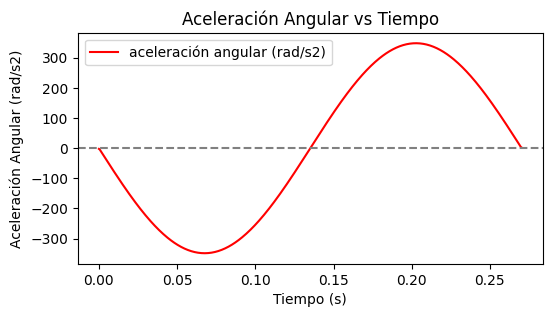

In [30]:
L_lab = 0.133 
penducle_ratio = 0.30
a_lab = 0.03
theta_max = float(smp.atan((a_lab/(L_lab*penducle_ratio))))
theta_max_deg = np.rad2deg(theta_max)

#linspace de thetas para un ciclo
theta_lins = np.linspace(-theta_max, theta_max, 500)

#linspace de tiempo de un ciclo
f = 3.7                   
T = 1 / f
tiempo = np.linspace(0, T, 500)

# Angulo como sine-wave
thetas_rad = theta_max * np.sin(2 * np.pi * f * tiempo)
omegas_rad = np.gradient(thetas_rad, tiempo)
alphas_rad = np.gradient(omegas_rad, tiempo)

plt.figure(figsize=(6,3))
plt.plot(tiempo, thetas_rad, label='angulo de la cola (deg)', color='k')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Angulo (rads)')
plt.title('Oscilacion de la cola')
plt.legend()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tiempo, omegas_rad, label='Velocidad Angular (rad/s)', color='b')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (rad/s)')
plt.title('Velocidad angular vs tiempo')
plt.legend()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tiempo, alphas_rad, label='aceleración angular (rad/s2)', color='r')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Aceleración Angular (rad/s2)')
plt.title('Aceleración Angular vs Tiempo')
plt.legend()
plt.show()

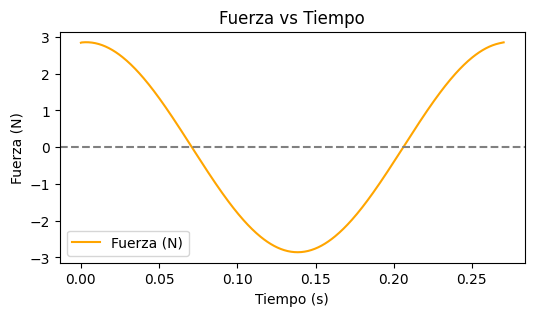

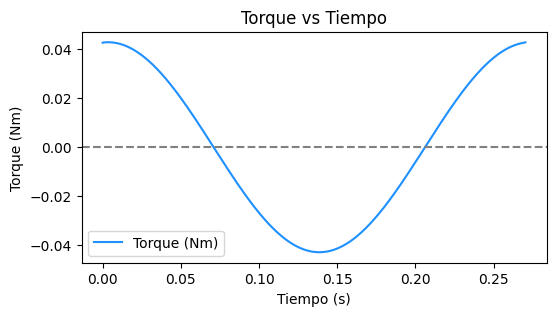

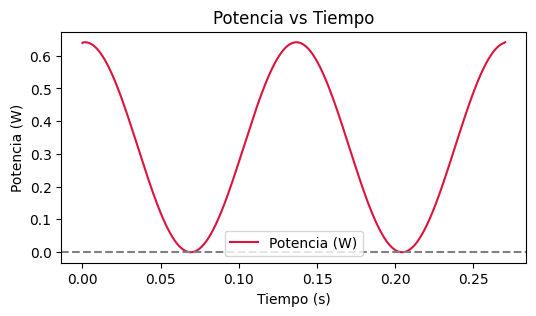

In [31]:
r = 0.015 #radio en el q aplico la fuerza
F = m*alphas_rad + cf*omegas_rad + kf*thetas_rad
tau = F*r
P = tau*omegas_rad

plt.figure(figsize=(6,3))
plt.plot(tiempo, F, label='Fuerza (N)', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Fuerza vs Tiempo')
plt.legend()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tiempo, tau, label='Torque (Nm)', color='dodgerblue')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Torque (Nm)')
plt.title('Torque vs Tiempo')
plt.legend()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tiempo, P, label='Potencia (W)', color='crimson')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencia (W)')
plt.title('Potencia vs Tiempo')
plt.legend()
plt.show()